In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
print(tf.__version__)

2.16.1


In [3]:
dataset_path = "../dataset"

In [4]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

Found 2936 files belonging to 6 classes.
Using 2349 files for training.


In [5]:
val_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

Found 2936 files belonging to 6 classes.
Using 587 files for validation.


In [8]:
class_names = train_dataset.class_names

print("Classes :", class_names)
print("Nombre de classes :", len(class_names))

Classes : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Nombre de classes : 6


In [9]:
print("Nombre de classes :", len(class_names))

Nombre de classes : 6


In [10]:
for i, class_name in enumerate(class_names):
    print(f"{i} : {class_name}")

0 : cardboard
1 : glass
2 : metal
3 : paper
4 : plastic
5 : trash


In [15]:
import os

dataset_path = "../dataset"

for class_name in class_names:
    
    class_path = os.path.join(dataset_path, class_name)
    
    num_images = len(os.listdir(class_path))
    
    print(f"{class_name} : {num_images} images")

cardboard : 402 images
glass : 501 images
metal : 409 images
paper : 594 images
plastic : 482 images
trash : 548 images


In [16]:
from PIL import Image

In [17]:
sample_image = "../dataset/plastic/plastic1.jpg"

img = Image.open(sample_image)

print("Taille image :", img.size)

Taille image : (512, 384)


In [18]:
print(img.mode)

RGB


(-0.5, 511.5, 383.5, -0.5)

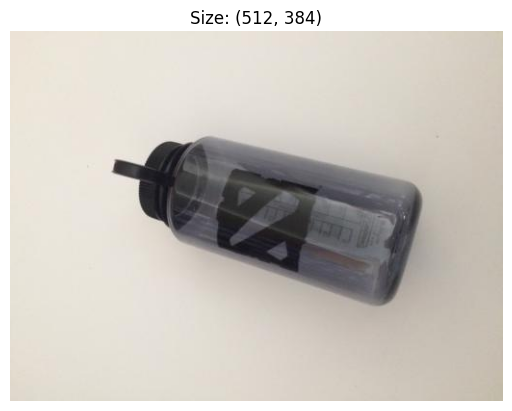

In [19]:
plt.imshow(img)

plt.title(f"Size: {img.size}")

plt.axis("off")

In [20]:
corrupted = []

for class_name in class_names:
    
    class_path = os.path.join(dataset_path, class_name)
    
    for image_name in os.listdir(class_path):
        
        image_path = os.path.join(class_path, image_name)
        
        try:
            img = Image.open(image_path)
            img.verify()
            
        except:
            corrupted.append(image_path)

In [21]:
print("Images corrompues :", len(corrupted))

Images corrompues : 0


In [22]:
image_counts = []

for class_name in class_names:
    
    class_path = os.path.join(dataset_path, class_name)
    
    image_counts.append(len(os.listdir(class_path)))

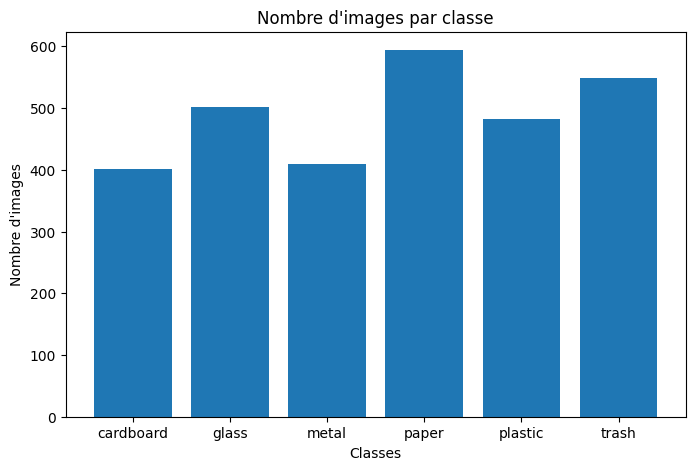

In [23]:
plt.figure(figsize=(8,5))

plt.bar(class_names, image_counts)

plt.title("Nombre d'images par classe")

plt.xlabel("Classes")
plt.ylabel("Nombre d'images")

plt.show()

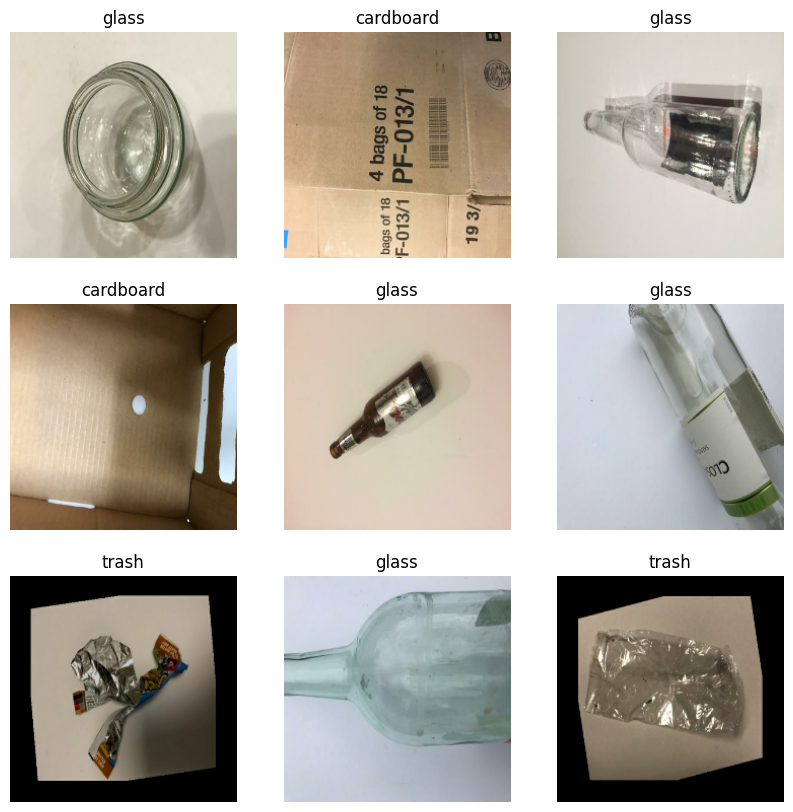

In [24]:
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])
        plt.axis("off")

In [25]:
for image_batch, labels_batch in train_dataset:
    print(image_batch.shape)
    print(labels_batch.shape)
    break

(32, 224, 224, 3)
(32,)


In [26]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

In [27]:
print("========== DATASET SUMMARY ==========")

print(f"Nombre de classes : {len(class_names)}")

print(f"Classes : {class_names}")

print(f"Nombre total d'images : {sum(image_counts)}")

========== DATASET SUMMARY ==========
Nombre de classes : 6
Classes : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Nombre total d'images : 2936


In [28]:
total_size = 0

for class_name in class_names:
    
    class_path = os.path.join(dataset_path, class_name)
    
    for image_name in os.listdir(class_path):
        
        image_path = os.path.join(class_path, image_name)
        
        total_size += os.path.getsize(image_path)

In [29]:
total_size_mb = total_size / (1024 * 1024)

print(f"Taille totale du dataset : {total_size_mb:.2f} MB")

Taille totale du dataset : 54.56 MB


In [30]:
total_images = sum(image_counts)

average_size = total_size_mb / total_images

print(f"Taille moyenne par image : {average_size:.4f} MB")

Taille moyenne par image : 0.0186 MB


In [31]:
for class_name in class_names:
    
    class_path = os.path.join(dataset_path, class_name)
    
    class_size = 0
    
    for image_name in os.listdir(class_path):
        
        image_path = os.path.join(class_path, image_name)
        
        class_size += os.path.getsize(image_path)
    
    class_size_mb = class_size / (1024 * 1024)
    
    print(f"{class_name} : {class_size_mb:.2f} MB")

cardboard : 7.23 MB
glass : 6.37 MB
metal : 6.93 MB
paper : 12.25 MB
plastic : 6.62 MB
trash : 15.17 MB
